In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["OMP_NUM_THREADS"] = "2"

import glob
import random
import numpy as np
import torch
import torchaudio
from tqdm import tqdm
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import normalized_mutual_info_score
import parselmouth
from parselmouth.praat import call
import math
from transformers import Wav2Vec2Model, Wav2Vec2Processor, Wav2Vec2FeatureExtractor

# -----------------------------
# CONFIG
# -----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAMPLE_RATE = 16000
MAX_FRAMES = 2_000_000   # subsample for clustering
N_CLUSTERS = 64         # tune once (50–200 typical)
BATCH_SIZE = 4
FACTOR = 0.1
MODEL = "facebook/mms-300m"
# -----------------------------
# LOAD MODEL
# -----------------------------
processor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL)
model = Wav2Vec2Model.from_pretrained(MODEL).to(DEVICE)
model.eval()

# -----------------------------
# TEXTGRID PARSING
# -----------------------------


def load_textgrid_phones(tg_path):
    tg = parselmouth.read(tg_path)

    n_tiers = call(tg, "Get number of tiers")

    for i in range(1, n_tiers + 1):
        name = call(tg, "Get tier name", i)
        if name == "phones":
            tier_index = i
            break
    else:
        raise ValueError("phones tier not found")

    intervals = []
    n_intervals = call(tg, "Get number of intervals", tier_index)

    for j in range(1, n_intervals + 1):
        start = call(tg, "Get start time of interval", tier_index, j)
        end = call(tg, "Get end time of interval", tier_index, j)
        label = call(tg, "Get label of interval", tier_index, j)

        if label.strip() == "":
            label = "sil"

        intervals.append((start, end, label))

    return intervals

# -----------------------------
# MAP FRAMES TO PHONEMES
# -----------------------------
def assign_labels_to_frames(frame_times, intervals):
    labels = []
    j = 0
    for t in frame_times:
        while j < len(intervals) - 1 and t > intervals[j][1]:
            j += 1
        labels.append(intervals[j][2])
    return labels

# -----------------------------
# EXTRACT EMBEDDINGS
# -----------------------------
@torch.no_grad()
def extract_embeddings_batch(wav_paths, devices):
    wavs = []
    lengths = []
    durations = []

    # -------- load + resample --------
    for wav_path in wav_paths:
        wav, sr = torchaudio.load(wav_path)
        wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
        wav = wav.mean(dim=0)
        wavs.append(wav.numpy())
        lengths.append(len(wav))
        durations.append(len(wav) / SAMPLE_RATE)

    # -------- tokenize (padding happens here) --------
    inputs = processor(
        wavs,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values

    # -------- split across GPUs --------
    chunks = torch.chunk(input_values, len(devices))

    all_hidden = []

    for chunk, device in zip(chunks, devices):
        chunk = chunk.to(device)
        model.to(device)

        outputs = model(chunk)
        hidden = outputs.last_hidden_state.cpu()  # (B, T, D)
        all_hidden.append(hidden)

    hidden = torch.cat(all_hidden, dim=0)  # (B, T, D)

    # -------- unpad + compute frame times --------
    results = []
    for i in range(len(wav_paths)):
        length = lengths[i]
        duration = durations[i]

        # approximate valid frames proportion
        total_frames = hidden.shape[1]
        valid_ratio = length / max(lengths)
        valid_frames = int(total_frames * valid_ratio)

        emb = hidden[i, :valid_frames].numpy()

        frame_times = np.linspace(0, duration, valid_frames)

        results.append((emb, frame_times))

    return results

def compute_nmi_for_language(lang_dir):
    wav_root = os.path.join(lang_dir, "textgrid_corpus_directory")
    tg_root = os.path.join(lang_dir, "alignments")

    if not os.path.exists(tg_root):
        print(f"{tg_root} doesn't exists, skipping")
    wav_files = glob.glob(os.path.join(wav_root, "**/*.wav"), recursive=True)
    wav_files = random.sample(wav_files, math.ceil(len(wav_files)*FACTOR))

    devices = ["cuda:0", "cuda:1"] if torch.cuda.device_count() >= 2 else [DEVICE]

    all_embeddings = []
    all_labels = []

    for i in tqdm(range(0, len(wav_files), BATCH_SIZE)):
        batch_paths = wav_files[i:i + BATCH_SIZE]

        valid_paths = []
        tg_paths = []

        for wav_path in batch_paths:
            rel_path = os.path.relpath(wav_path, wav_root)
            tg_path = os.path.join(tg_root, os.path.splitext(rel_path)[0] + ".TextGrid")

            if os.path.exists(tg_path):
                valid_paths.append(wav_path)
                tg_paths.append(tg_path)

        if len(valid_paths) == 0:
            continue

        try:
            batch_results = extract_embeddings_batch(valid_paths, devices)

            for (emb, frame_times), tg_path in zip(batch_results, tg_paths):
                intervals = load_textgrid_phones(tg_path)
                labels = assign_labels_to_frames(frame_times, intervals)

                all_embeddings.append(emb)
                all_labels.extend(labels)

        except Exception as e:
            print(f"Skipping batch: {e}")

    if len(all_embeddings) == 0:
        return None

    X = np.concatenate(all_embeddings, axis=0)
    y = np.array(all_labels)

    # subsample
    if len(X) > math.ceil(MAX_FRAMES*FACTOR):
        idx = np.random.choice(len(X), math.ceil(MAX_FRAMES*FACTOR), replace=False)
        X = X[idx]
        y = y[idx]

    # normalize
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1
    X = X / norms

    X = X.astype(np.float16)

    kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, batch_size=16384)
    cluster_ids = kmeans.fit_predict(X)

    nmi = normalized_mutual_info_score(y, cluster_ids)

    return nmi

# -----------------------------
# RUN FOR ALL LANGUAGES
# -----------------------------
def run_all(root="processed_data"):
    langs = [os.path.join(root, l) for l in os.listdir(root)]

    results = {}
    for lang in langs:
        print(f"\n=== {lang} ===")
        nmi = compute_nmi_for_language(lang)
        results[os.path.basename(lang)] = nmi
        print(f"NMI: {nmi}")

    return results

if __name__ == "__main__":
    results = run_all("processed_data")
    print(results)

/localscratch/nnsfn01/anaconda3/envs/north_caucasian_asr/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== processed_data/lg_ug ===


100%|███████████████████████████████████████████| 62/62 [01:18<00:00,  1.27s/it]


NMI: 0.08935050122878559

=== processed_data/mr_in ===


100%|███████████████████████████████████████████| 82/82 [01:29<00:00,  1.09s/it]


...

NMI: 0.13223071339074446

=== processed_data/tg_tj ===


100%|███████████████████████████████████████████| 58/58 [01:04<00:00,  1.11s/it]


NMI: 0.2669320387365674

=== processed_data/ha_ng ===


100%|███████████████████████████████████████████| 82/82 [01:44<00:00,  1.27s/it]


NMI: 0.25010397952211144
{'lg_ug': 0.08935050122878559, 'mr_in': 0.08651737129069056, 'nb_no': 0.1728688663117075, 'ig_ng': None, 'so_so': 0.2344822633930575, 'fi_fi': 0.2345838274937738, 'hi_in': 0.22022638702712777, 'pa_in': 0.09702531411351539, 'nso_za': None, 'bn_in': 0.12865976912384786, 'az_az': 0.10559757286716656, 'be_by': 0.250875820824889, 'ln_cd': None, 'pl_pl': 0.2535349523581616, 'es_419': 0.1258467961428598, 'bs_ba': None, 'luo_ke': None, 'fil_ph': None, 'cs_cz': 0.21229533703389783, 'as_in': None, 'sk_sk': None, 'ceb_ph': 0.07614770048017502, 'oc_fr': None, 'mn_mn': 0.132237242090343, 'en_us': 0.22131945008656667, 'bg_bg': 0.058413015147680165, 'kn_in': 0.0891809708935775, 'ky_kg': 0.25858332326348266, 'ja_jp': 0.09849029577421803, 'am_et': 0.08999953752549636, 'ny_mw': 0.20490791779533013, 'umb_ao': None, 'ps_af': 0.05704693028217192, 'id_id': 0.21541511615732833, 'yo_ng': 0.23914597821385938, 'ff_sn': 0.20686004585596318, 'ka_ge': 0.08269078426069358, 'gu_in': None, 'v

In [5]:
import collections

results = collections.OrderedDict(sorted(results.items()))

In [27]:
count = 0
for l, sc in results.items():
    if sc and l:
        if sc > 0.15:
            count += 1
        print(f"{l:<10}\t{sc:.2f}") 
print(count)

af_za     	0.14
am_et     	0.09
ar_eg     	0.20
ast_es    	0.13
az_az     	0.11
be_by     	0.25
bg_bg     	0.06
bn_in     	0.13
ca_es     	0.22
ceb_ph    	0.08
ckb_iq    	0.12
cmn_hans_cn	0.26
cs_cz     	0.21
cy_gb     	0.09
da_dk     	0.11
de_de     	0.25
el_gr     	0.08
en_us     	0.22
es_419    	0.13
et_ee     	0.22
fa_ir     	0.17
ff_sn     	0.21
fi_fi     	0.23
fr_fr     	0.11
ga_ie     	0.08
gl_es     	0.13
ha_ng     	0.25
he_il     	0.15
hi_in     	0.22
hr_hr     	0.29
hu_hu     	0.22
hy_am     	0.24
id_id     	0.22
it_it     	0.13
ja_jp     	0.10
jv_id     	0.18
ka_ge     	0.08
kk_kz     	0.26
km_kh     	0.13
kn_in     	0.09
ko_kr     	0.13
ky_kg     	0.26
lg_ug     	0.09
lo_la     	0.27
lt_lt     	0.24
lv_lv     	0.25
mi_nz     	0.24
mk_mk     	0.26
ml_in     	0.13
mn_mn     	0.13
mr_in     	0.09
ms_my     	0.06
mt_mt     	0.20
my_mm     	0.16
nb_no     	0.17
ne_np     	0.25
nl_nl     	0.14
ny_mw     	0.20
om_et     	0.18
or_in     	0.24
pa_in     	0.10
pl_pl     	0.25
ps_af  

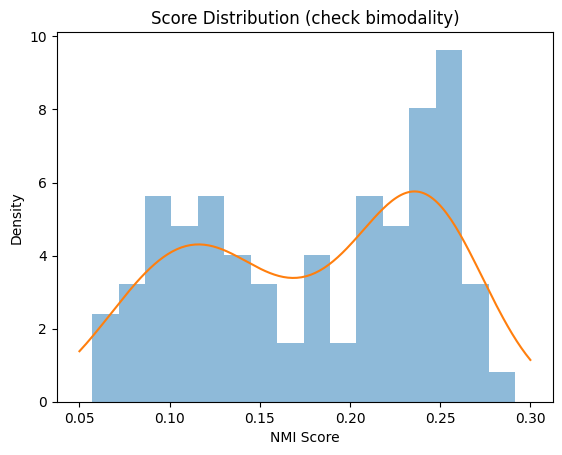

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

scores = list(results.values())
scores = [sc for sc in scores if sc]
plt.figure()

# histogram
plt.hist(scores, bins=16, density=True, alpha=0.5)

# KDE curve
kde = gaussian_kde(scores)
x = np.linspace(0.05, 0.30, 200)
plt.plot(x, kde(x))

plt.xlabel("NMI Score")
plt.ylabel("Density")
plt.title("Score Distribution (check bimodality)")

plt.show()